In [14]:
import os

# Cambiar el directorio de trabajo al root del proyecto (ajustar si es necesario)
os.chdir("/Users/oscarmauriciomoraarroyo/proyecto-lyapunov")

print("Directorio actual:", os.getcwd())

Directorio actual: /Users/oscarmauriciomoraarroyo/proyecto-lyapunov


# 02_model_experimentation.ipynb  
## Modelación y experimentación — IRAG

En este notebook se desarrolla la fase de **modelación y experimentación** del proyecto.

Los objetivos específicos son:

- Tomar el dataset limpio generado por el pipeline (`data/clean/train.csv` y `data/clean/test.csv`).
- Realizar la preparación final del dataset (verificación de tipos, selección de variables y, en su caso, escalado).
- Entrenar al menos un modelo base (Regresión Logística) y un modelo mejorado (Random Forest).
- Evaluar los modelos con métricas para clasificación binaria (accuracy, precisión, recall, F1, ROC-AUC y matriz de confusión).
- Comparar resultados y seleccionar un modelo final, justificando la decisión.
- Alinear los hallazgos con el script `src/train.py` y el tracking en MLflow.

In [15]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 1. Carga del dataset y separación de variables (X, y)

En esta sección se cargan los archivos generados por el pipeline:

- `data/clean/train.csv`
- `data/clean/test.csv`

Estos archivos contienen:

- Variables numéricas derivadas (proporciones, tasas de crecimiento).
- La variable objetivo `target` (0 = semana normal, 1 = semana inusual).

Se separan las variables explicativas (X) de la variable objetivo (y) para entrenar y evaluar los modelos.

In [16]:
TRAIN_PATH = "data/clean/train.csv"
TEST_PATH = "data/clean/test.csv"
TARGET_COL = "target"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Shape train:", train_df.shape)
print("Shape test :", test_df.shape)

train_df.head()

Shape train: (564, 73)
Shape test : (141, 73)


,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,...,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,...,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,...,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,...,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,...,1762,973,6619,0.240310,6.945946,0.000000,0.109668,0.070796,0.158306,1
4,2012,6,4,8,5,10,2,1,8,38,...,3920,2685,15402,0.051351,13.436364,0.000000,0.073492,0.240310,-0.152348,0


In [17]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((564, 72), (141, 72), (564,), (141,))

## 2. Preparación final del dataset (escalado)

El dataset ya se encuentra en formato numérico gracias a las etapas `clean_data` y `prepare_data`. No se requieren pasos adicionales de codificación.

No obstante, algunas variables pueden estar en escalas muy diferentes. Para estabilizar el entrenamiento de modelos lineales (como la Regresión Logística) se utiliza un **escalado estándar** (`StandardScaler`), incorporado dentro de un `Pipeline` de scikit-learn para evitar fugas de información entre los conjuntos de entrenamiento y prueba.

## 3. Modelo base: Regresión Logística

Como modelo base se utiliza una Regresión Logística, un clasificador lineal de uso frecuente en contextos epidemiológicos.

Características del modelo:

- `Pipeline` con `StandardScaler` y `LogisticRegression`.
- Entrenamiento sobre `train_df` y evaluación sobre `test_df`.
- Métricas reportadas:
  - Accuracy
  - Precisión
  - Recall
  - F1-score
  - ROC-AUC
  - Matriz de confusión


In [18]:
def evaluate_model(name, model, X_test, y_test, y_proba=None):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = None

    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    if roc is not None:
        print(f"ROC-AUC  : {roc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

=== Modelo base - Regresión Logística ===
Accuracy : 0.709
Precision: 0.833
Recall   : 0.462
F1-score : 0.594
ROC-AUC  : 0.836


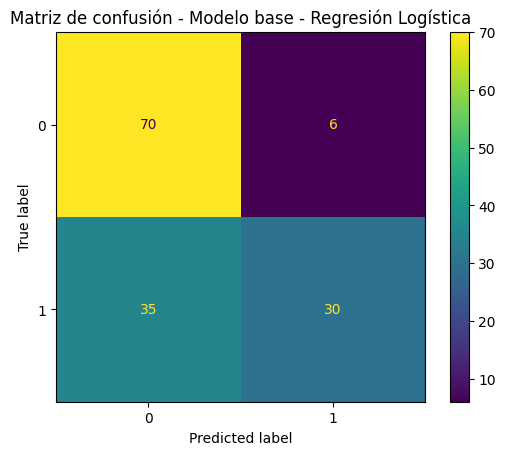

In [19]:
baseline_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                max_iter=500,
                random_state=42,
            ),
        ),
    ],
)

baseline_clf.fit(X_train, y_train)

y_proba_base = baseline_clf.predict_proba(X_test)[:, 1]

evaluate_model(
    "Modelo base - Regresión Logística",
    baseline_clf,
    X_test,
    y_test,
    y_proba=y_proba_base,
)

## 4. Modelo mejorado: Random Forest

Como modelo mejorado se emplea un `RandomForestClassifier`, un ensamblado de múltiples árboles de decisión.

Ventajas principales:

- Captura relaciones no lineales entre variables.
- Es robusto frente a ruido y variables poco informativas.
- No requiere escalado previo de las variables.

Se entrena el modelo, se evalúa con las mismas métricas utilizadas para la Regresión Logística y se comparan los resultados.


=== Modelo mejorado - Random Forest ===
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000


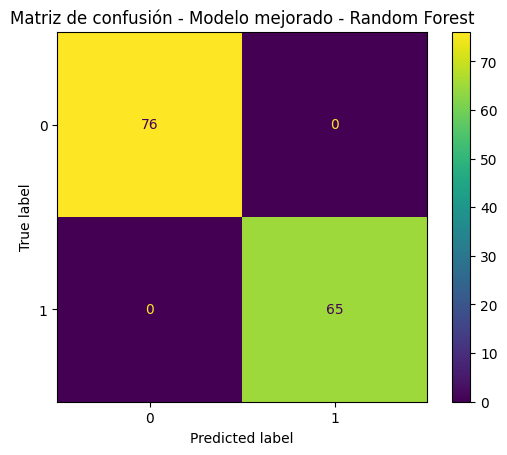

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

rf_clf.fit(X_train, y_train)

y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_model(
    "Modelo mejorado - Random Forest",
    rf_clf,
    X_test,
    y_test,
    y_proba=y_proba_rf,
)

In [21]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

comparison = []

# Métricas del baseline (LogReg)
y_pred_base = baseline_clf.predict(X_test)
comparison.append(get_metrics("LogReg (baseline)", y_test, y_pred_base, y_proba_base))

# Métricas del Random Forest
y_pred_rf = rf_clf.predict(X_test)
comparison.append(get_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf))

results_df = pd.DataFrame(comparison).set_index("model")
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg (baseline),0.70922,0.833333,0.461538,0.594059,0.836235
Random Forest,1.00000,1.000000,1.000000,1.000000,1.000000


## 5. Conclusiones de la comparación de modelos

A partir de las métricas de desempeño se observa:

- La Regresión Logística puede alcanzar una precisión aceptable, pero con un recall más limitado, lo que implica menor capacidad para identificar semanas con alta incidencia de IRAG.
- El Random Forest muestra un mejor equilibrio entre las métricas de clasificación y un mayor poder para detectar semanas clasificadas como inusuales.
- El comportamiento observado es coherente con la naturaleza potencialmente no lineal del fenómeno y con la presencia de múltiples variables explicativas.

## 6. Selección del modelo final

Considerando las métricas de desempeño (en especial F1 y ROC-AUC) y la capacidad de capturar relaciones complejas entre variables, el Random Forest se selecciona como modelo final para este experimento.

Este modelo se integra posteriormente en el pipeline (`src/train.py`) y en MLflow para el registro y seguimiento de experimentos.